In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [32]:
import pandas as pd
import numpy as np
import torch

from numba import typeof
from sklearn.preprocessing import StandardScaler

from src.features import cycle
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from pytorch_lightning.callbacks import EarlyStopping
from darts.models import TFTModel

In [33]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [34]:
def preprocessing_data(df, days_since_start = 0):
    df.columns = [col.replace(',', '.') for col in df.columns]
    df['days_since_start'] = (df['Дата'] - df['Дата'].min()).dt.days + days_since_start
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    df.rename(columns={'48-Воздух (0)': 'air_temp'}, inplace=True)

    df['is_anomaly'] = np.where(df['Дата'] <= '2021-05-17', 1, 0)

    df_long = pd.melt(
        df,
        id_vars=['Дата', 'air_temp', 'День', 'Месяц', 'Год', 'is_anomaly', 'day_of_year','Месяц_sin', 'Месяц_cos', 'day_of_year_sin' ,'day_of_year_cos', 'days_since_start'],
        var_name='sensor_name',
        value_name='temperature'
    )

    df_long['depth_val'] = df_long['sensor_name'].str.extract(r'\((.*?)\)')[0].astype(float)
    df_long = df_long.drop(columns=['sensor_name'])

    df_long = df_long.sort_values(by=['depth_val', 'Дата'])

    df_long['temperature'] = df_long.groupby('depth_val')['temperature'].transform(
        lambda group: group.interpolate(method='linear', limit_direction='both')
    )
    df_long['air_temp'] = df_long.groupby('depth_val')['air_temp'].transform(
        lambda group: group.interpolate(method='linear', limit_direction='both')
    )

    for window in [14, 60]:
        df_long[f'air_temp_ma_{window}d'] = df_long['air_temp'].rolling(window, min_periods=1).mean()

    df_long['depth_id'] = df_long['depth_val'].astype(str)

    return df_long


In [35]:
def create_darts_dataset(df):
    df['depth_id'] = df['depth_id'].astype('category').cat.codes
    targets = TimeSeries.from_group_dataframe(
        df,
        time_col='Дата',
        group_cols='depth_id',
        value_cols='temperature',
        static_cols=['depth_val']
    )

    past_covs = TimeSeries.from_group_dataframe(
        df,
        time_col='Дата',
        group_cols='depth_id',
        value_cols=['air_temp', 'is_anomaly','air_temp_ma_60d','air_temp_ma_14d']
    )

    future_covs = TimeSeries.from_group_dataframe(
        df,
        time_col='Дата',
        group_cols='depth_id',
        value_cols=[
            'Месяц_sin', 'Месяц_cos',
            'day_of_year_sin', 'day_of_year_cos',
            'День', 'Месяц', 'Год', 'day_of_year', 'days_since_start'
        ]
    )

    return targets, past_covs, future_covs

train_prep = preprocessing_data(df_train)
train_darts = create_darts_dataset(train_prep)

val_prep = preprocessing_data(df_val, days_since_start=len(df_train))
val_darts = create_darts_dataset(val_prep)

In [36]:
target_scaler = Scaler(scaler=StandardScaler())
past_air_scaler = Scaler(scaler=StandardScaler())
future_scaler = Scaler(scaler=StandardScaler())

train_targets, train_past, train_future = train_darts

t_scaled_targets = target_scaler.fit_transform(train_targets)

train_air = [ts['air_temp'] for ts in train_past]
scaled_t_air = past_air_scaler.fit_transform(train_air)
train_anomaly = [ts['is_anomaly'] for ts in train_past]
t_scaled_past = [air.stack(anom) for air, anom in zip(scaled_t_air, train_anomaly)]
t_scaled_future = future_scaler.fit_transform(train_future)


val_targets, val_past, val_future = val_darts
val_scaled_targets = target_scaler.transform(val_targets)
val_air = [ts['air_temp'] for ts in val_past]
scaled_v_air = past_air_scaler.transform(val_air)
val_anomaly = [ts['is_anomaly'] for ts in val_past]
v_scaled_past = [air.stack(anom) for air, anom in zip(scaled_v_air, val_anomaly)]

v_scaled_future = future_scaler.transform(val_future)

In [37]:
from pytorch_lightning.callbacks import TQDMProgressBar


class SilentValProgressBar(TQDMProgressBar):
    def init_validation_tqdm(self):
        bar = super().init_validation_tqdm()
        bar.disable = True
        return bar
silent_progress_bar = SilentValProgressBar()

In [38]:
from pytorch_lightning.callbacks import Callback, EarlyStopping
from optuna.exceptions import TrialPruned

class OptunaPruningCallback(Callback):
    def __init__(self, trial, monitor="val_loss"):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_validation_epoch_end(self, trainer, pl_module):
        logs = trainer.callback_metrics
        if self.monitor in logs:
            current_score = logs[self.monitor].item()
            epoch = trainer.current_epoch
            self.trial.report(current_score, step=epoch)
            if self.trial.should_prune():
                raise TrialPruned()

In [39]:
import optuna
from darts.models import TFTModel
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

IN_LEN = 180
OUT_LEN = 180

def objective(trial):
    hidden_size = trial.suggest_categorical("hidden_size", [32, 64])
    lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
    num_attention_heads = trial.suggest_categorical("num_attention_heads", [4, 8])
    dropout = trial.suggest_float("dropout", 0.05, 0.3, step=0.05)
    batch_size = trial.suggest_categorical("batch_size", [64, 128])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    pruning_callback = OptunaPruningCallback(trial, monitor="val_loss")
    early_stopper = EarlyStopping(
        monitor="val_loss",
        patience=3,
        min_delta=1e-5,
        mode="min"
    )

    model = TFTModel(
        input_chunk_length=IN_LEN,
        output_chunk_length=OUT_LEN,
        hidden_size=hidden_size,
        lstm_layers=lstm_layers,
        num_attention_heads=num_attention_heads,
        dropout=dropout,
        batch_size=batch_size,
        n_epochs=50,
        add_relative_index=True,
        add_encoders=None,
        random_state=42,
        loss_fn=torch.nn.MSELoss(),
        model_name=f"tft_optuna_trial_{trial.number}",
        save_checkpoints=False,
        pl_trainer_kwargs={"callbacks": [early_stopper, silent_progress_bar, pruning_callback]},
        optimizer_kwargs={"lr": lr}
    )


    model.fit(
        series=t_scaled_targets,
        past_covariates=t_scaled_past,
        future_covariates=t_scaled_future,
        val_series=val_scaled_targets,
        val_past_covariates=v_scaled_past,
        val_future_covariates=v_scaled_future,
        verbose=False
    )


    val_loss = model.trainer.callback_metrics.get("val_loss")

    if val_loss is None:
        raise ValueError("val_loss не найден в callback_metrics. Проверьте параметры обучения.")

    return float(val_loss)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("Лучшие параметры:", study.best_params)
print("Лучший val_loss:", study.best_value)

[I 2026-05-27 17:14:03,531] A new study created in memory with name: no-name-e08b22b0-0bfd-4372-b031-31d49c47284a
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | MSELoss                          | 0      | train
1  | train_criterion                   | MSELoss                         

Epoch 1:   0%|          | 0/103 [00:00<?, ?it/s, train_loss=0.0359, val_loss=0.088]          

C:\Users\mefod\AppData\Local\Temp\ipykernel_18816\1635517261.py:15: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self.trial.report(current_score, step=epoch)


Epoch 12: 100%|██████████| 103/103 [01:56<00:00,  0.88it/s, train_loss=0.00409, val_loss=0.0646]

[I 2026-05-27 17:39:19,982] Trial 0 finished with value: 0.0646225716333299 and parameters: {'hidden_size': 64, 'lstm_layers': 2, 'num_attention_heads': 4, 'dropout': 0.25, 'batch_size': 128, 'lr': 0.0009673622500552224}. Best is trial 0 with value: 0.0646225716333299.
GPU available: True (cuda), used: True


...

Epoch 1:   0%|          | 0/103 [00:00<?, ?it/s, train_loss=0.0446, val_loss=0.094]          

C:\Users\mefod\AppData\Local\Temp\ipykernel_18816\1635517261.py:15: UserWarning: The reported value is ignored because this `step` 0 is already reported.
  self.trial.report(current_score, step=epoch)


Epoch 1: 100%|██████████| 103/103 [09:55<00:00,  0.17it/s, train_loss=0.0261, val_loss=0.094]
Validation: |          | 0/? [00:00<?, ?it/s]

[I 2026-05-27 19:28:27,037] Trial 19 pruned. 


Лучшие параметры: {'hidden_size': 32, 'lstm_layers': 1, 'num_attention_heads': 8, 'dropout': 0.25, 'batch_size': 128, 'lr': 0.0021816927428442456}
Лучший val_loss: 0.062251830630564685


In [48]:
torch.cuda.empty_cache()

In [56]:
early_stopper = EarlyStopping(
        monitor="val_loss",
        patience=3,
        min_delta=1e-5,
        mode="min"
    )
silent_progress_bar = SilentValProgressBar()
model = TFTModel(
        input_chunk_length=IN_LEN,
        output_chunk_length=OUT_LEN,
        hidden_size=32,
        lstm_layers=1,
        num_attention_heads=8,
        dropout=0.25,
        batch_size=128,
        n_epochs=50,
        likelihood=None,
        add_relative_index=True,
        add_encoders=None,
        random_state=42,
        loss_fn=torch.nn.MSELoss(),
        model_name=f"tft_180_180_best_optuna",
        save_checkpoints=True,
        pl_trainer_kwargs={"callbacks": [early_stopper, silent_progress_bar]},
        optimizer_kwargs={"lr": 0.0021816927428442456}
    )


model.fit(
    series=t_scaled_targets,
    past_covariates=t_scaled_past,
    future_covariates=t_scaled_future,
    val_series=val_scaled_targets,
    val_past_covariates=v_scaled_past,
    val_future_covariates=v_scaled_future,
    verbose=False
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | MSELoss                          | 0      | train
1  | train_criterion                   | MSELoss                          | 0      | train
2  | val_criterion                     | MSELoss                          | 0      | train
3  | train_metrics                     | MetricCollection                 | 0      | train
4  | val_metrics                       | MetricCollection                 | 0      | train
5  | input_embeddings                  | _MultiEmbedding                  | 0      | train
6  | static_covariates_vsn             | _VariableSelectionNetwork        | 1.9 K  | train
7  | encoder_vsn

Epoch 7: 100%|██████████| 103/103 [01:31<00:00,  1.13it/s, train_loss=0.00586, val_loss=0.0623]


TFTModel(output_chunk_shift=0, hidden_size=32, lstm_layers=1, num_attention_heads=8, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.25, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=True, skip_interpolation=False, loss_fn=MSELoss(), likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=180, output_chunk_length=180, batch_size=128, n_epochs=50, add_encoders=None, random_state=42, model_name=tft_180_180_best_optuna, save_checkpoints=False, pl_trainer_kwargs={'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x000002FAB85C4980>, <__main__.SilentValProgressBar object at 0x000002FAB85C6C90>]}, optimizer_kwargs={'lr': 0.0021816927428442456})

In [ ]:
model.save("tft_180_180_best_optuna.pt")

In [68]:
model = TFTModel.load("tft_180_180_best_optuna.pt")
#model = TFTModel.load_from_checkpoint(model_name=f"tft_180_170.pt", best=True)
test_prep = preprocessing_data(df_test, days_since_start=len(df_train_full))
test_darts = create_darts_dataset(test_prep)

test_targets, test_past, test_future = test_darts

test_scaled_targets = target_scaler.transform(test_targets)

test_air = [ts['air_temp'] for ts in test_past]
scaled_test_air = past_air_scaler.transform(test_air)
test_anomaly = [ts['is_anomaly'] for ts in test_past]
test_scaled_past = [air.stack(anom) for air, anom in zip(scaled_test_air, test_anomaly)]

test_scaled_future = future_scaler.transform(test_future)
combined_past = []
for val_past, test_past in zip(v_scaled_past, test_scaled_past):
    combined_past.append(val_past.append(test_past))

combined_future = []
for val_fut, test_fut in zip(v_scaled_future, test_scaled_future):
    combined_future.append(val_fut.append(test_fut))
n_forecast = len(df_test['Дата'].unique())
pred_scaled = model.predict(
    n=n_forecast,
    series=val_scaled_targets,
    past_covariates=combined_past,
    future_covariates=combined_future,
)


predictions = target_scaler.inverse_transform(pred_scaled)
n_forecast

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
Dataset output has a different data type than the dataset the model was trained on; current data type: float64, expected data type: float64. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  2.31it/s]


349

Метрики по глубинам:
 Depth, m   MAE  RMSE
    0.000 3.227 3.896
    0.500 2.238 2.863
    1.000 1.778 2.361
    1.500 1.355 1.966
   10.000 0.249 0.328
   11.000 0.143 0.208
    2.000 1.025 1.751
    2.500 0.757 1.455
    3.000 0.582 1.122
    3.500 0.542 0.924
    4.000 0.484 0.732
    4.500 0.473 0.685
    5.000 0.467 0.650
    6.000 0.406 0.580
    7.000 0.349 0.520
    8.000 0.283 0.445
    9.000 0.228 0.352

Средние метрики:
MAE  = 0.858
RMSE = 1.226


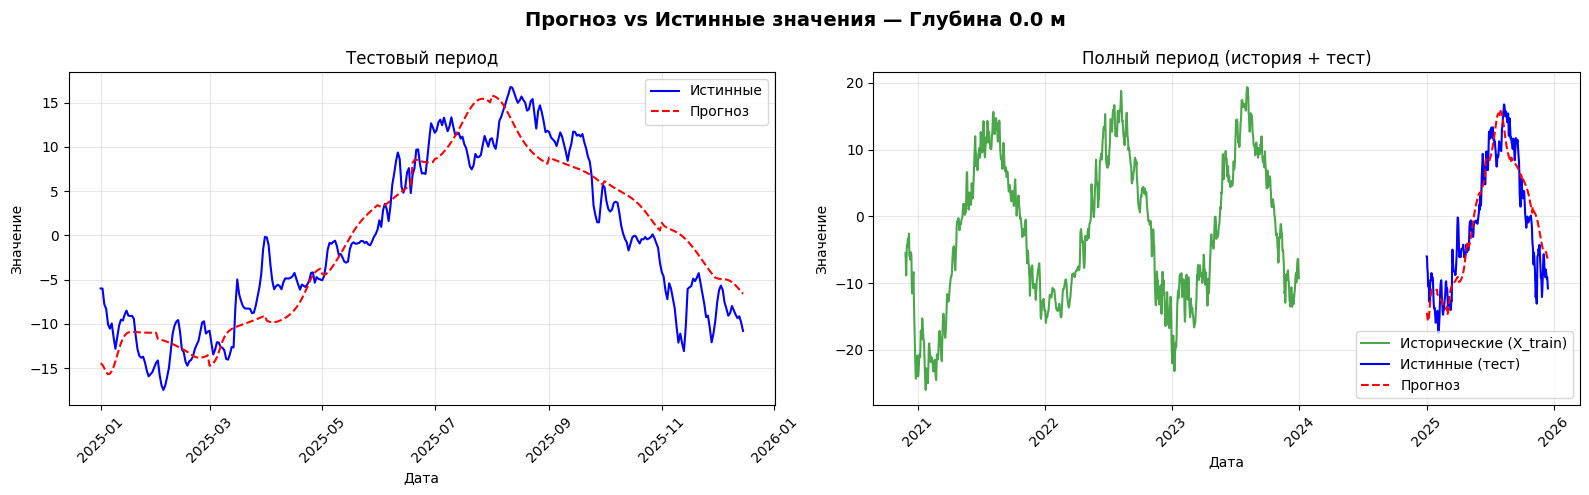

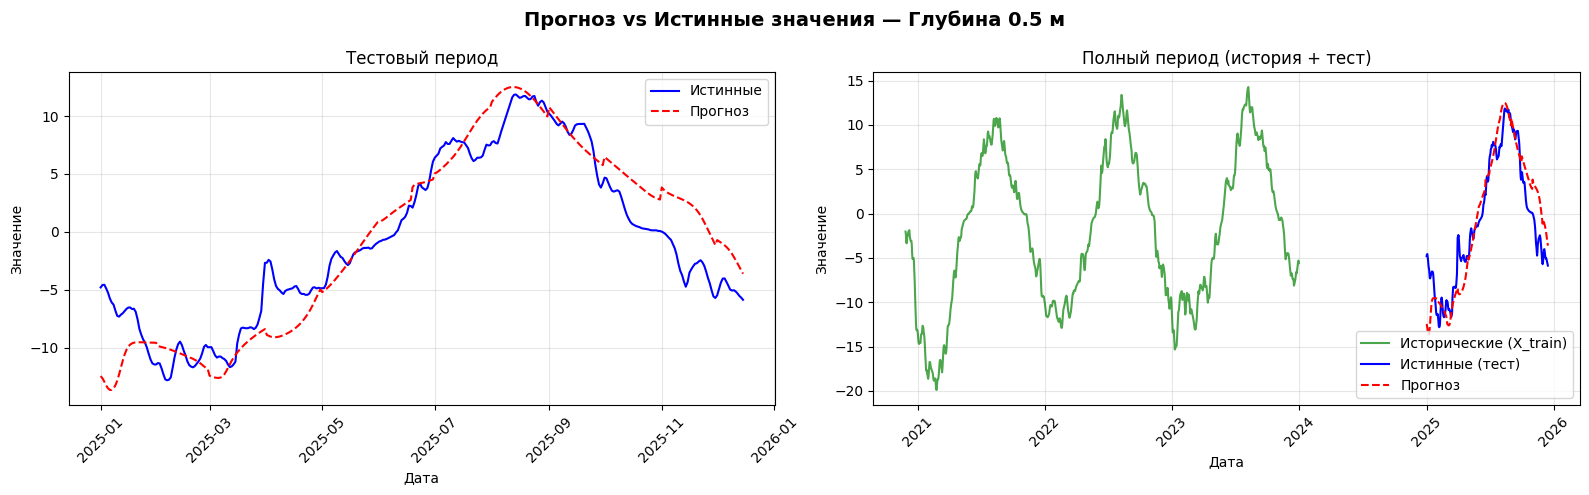

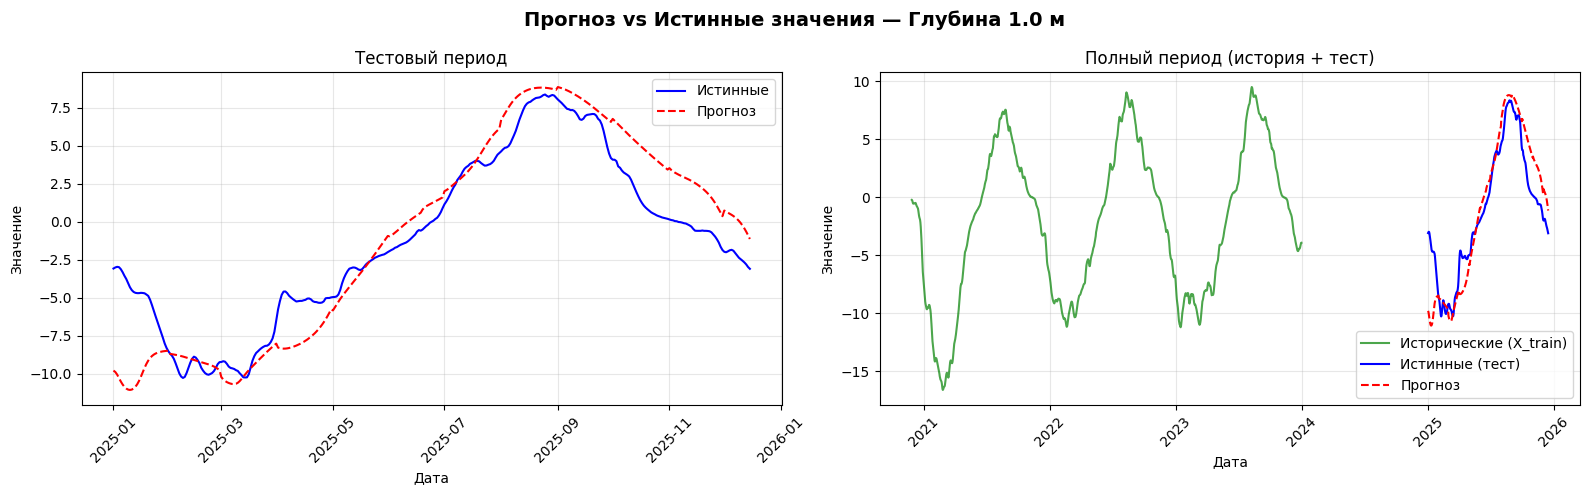

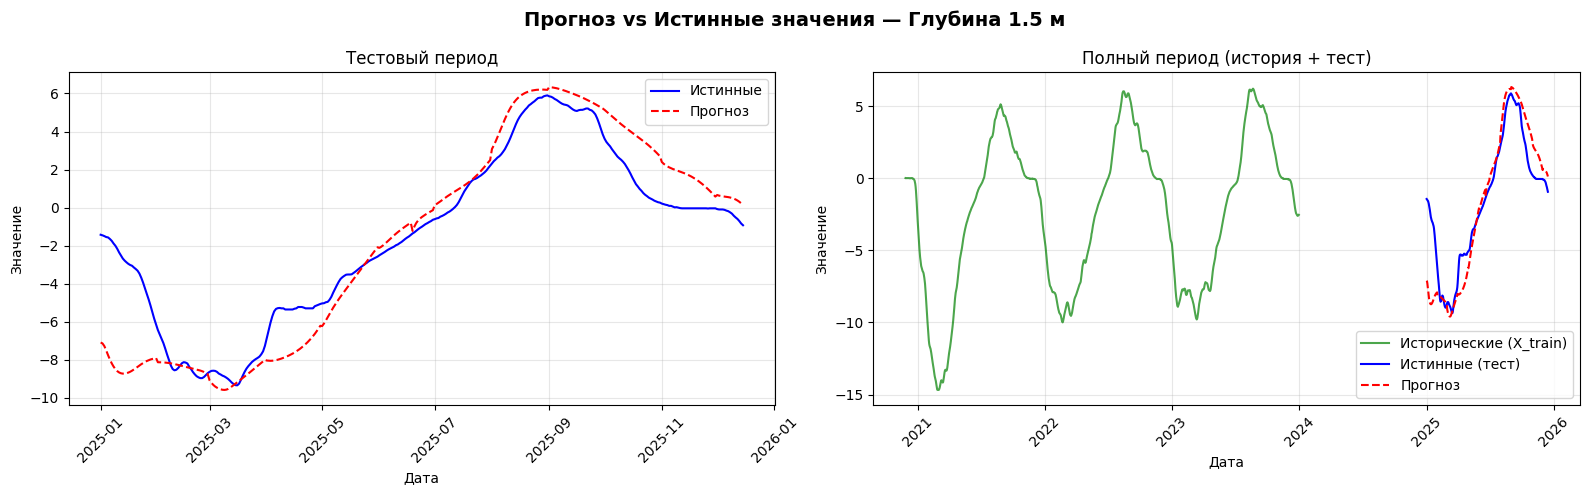

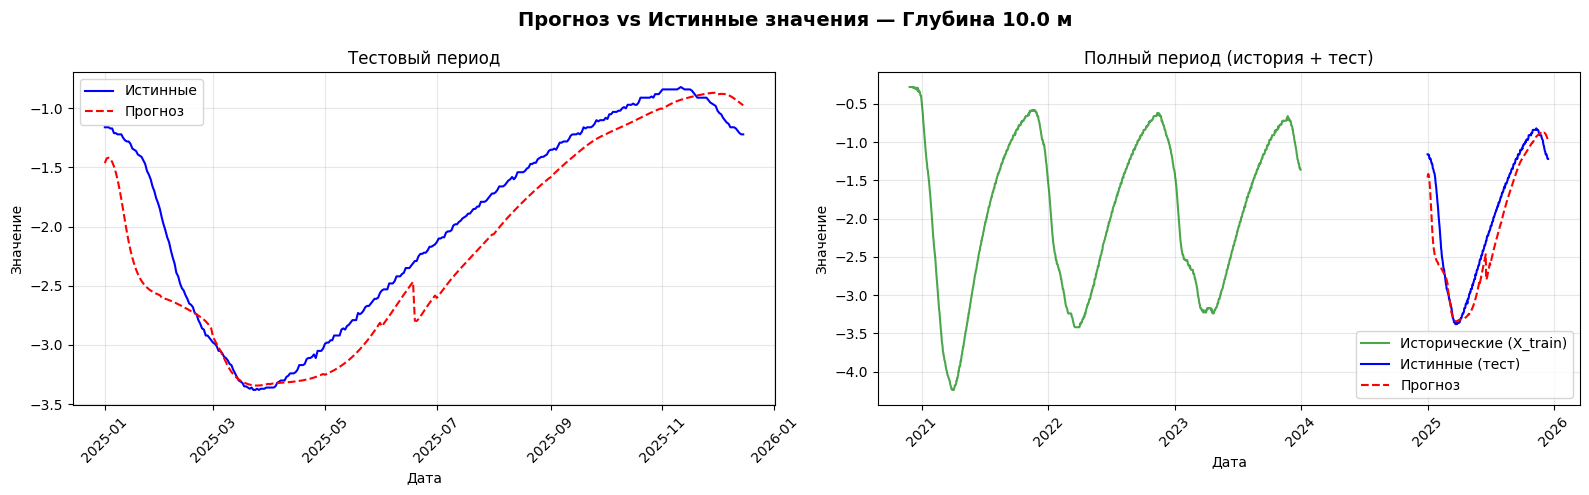

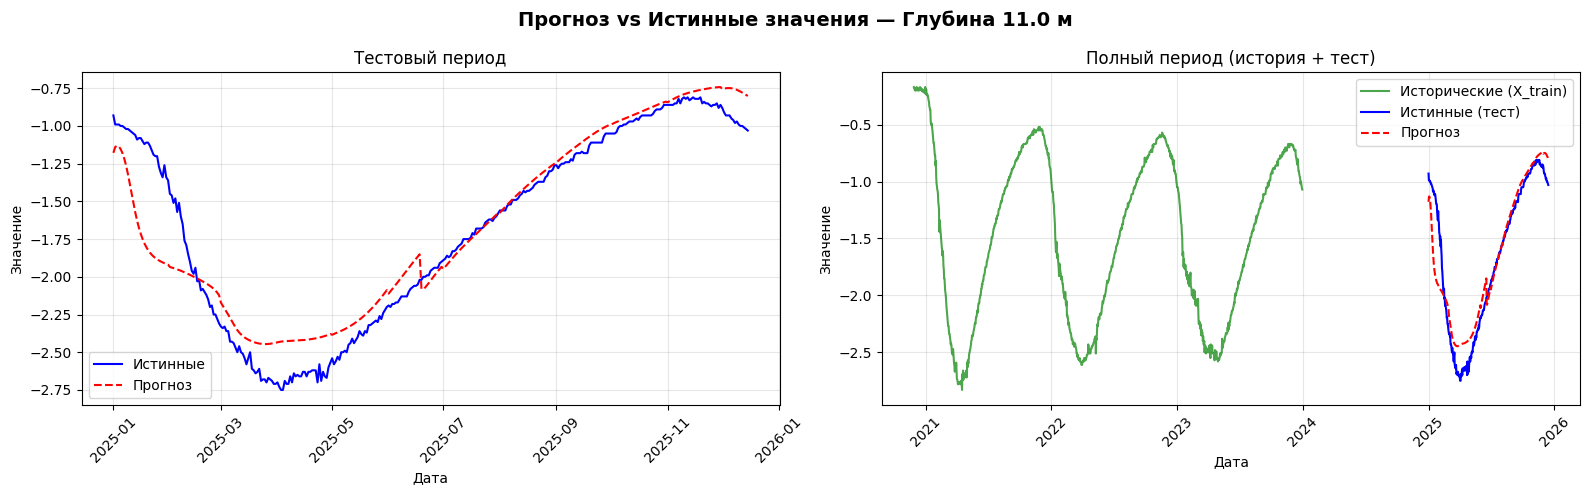

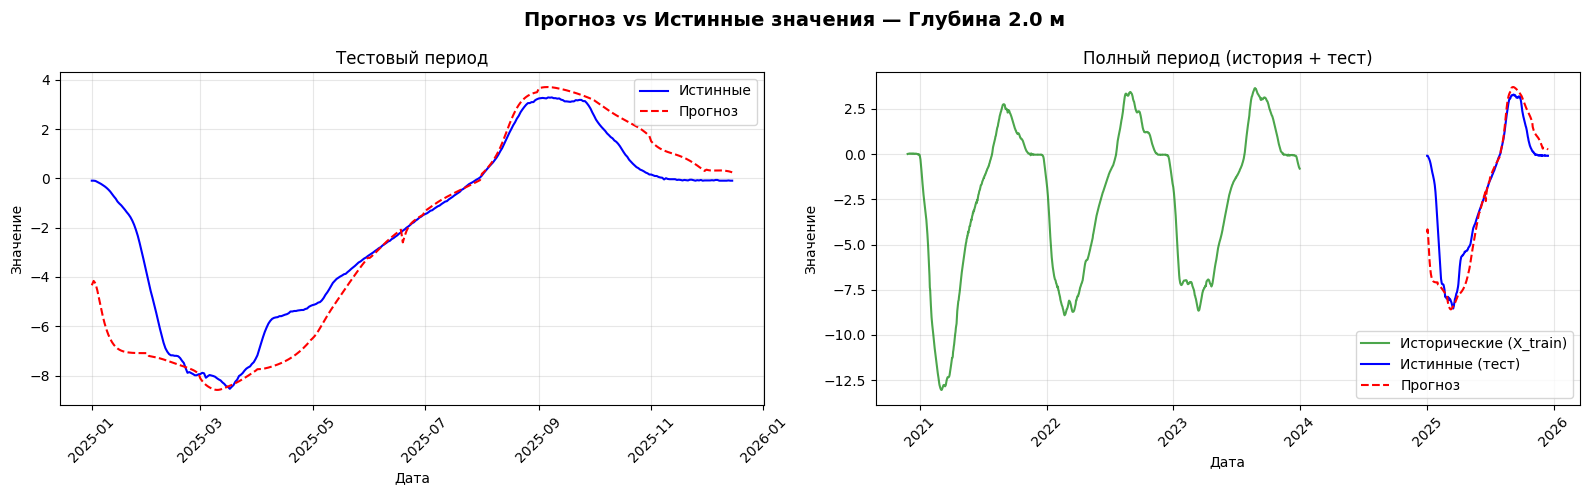

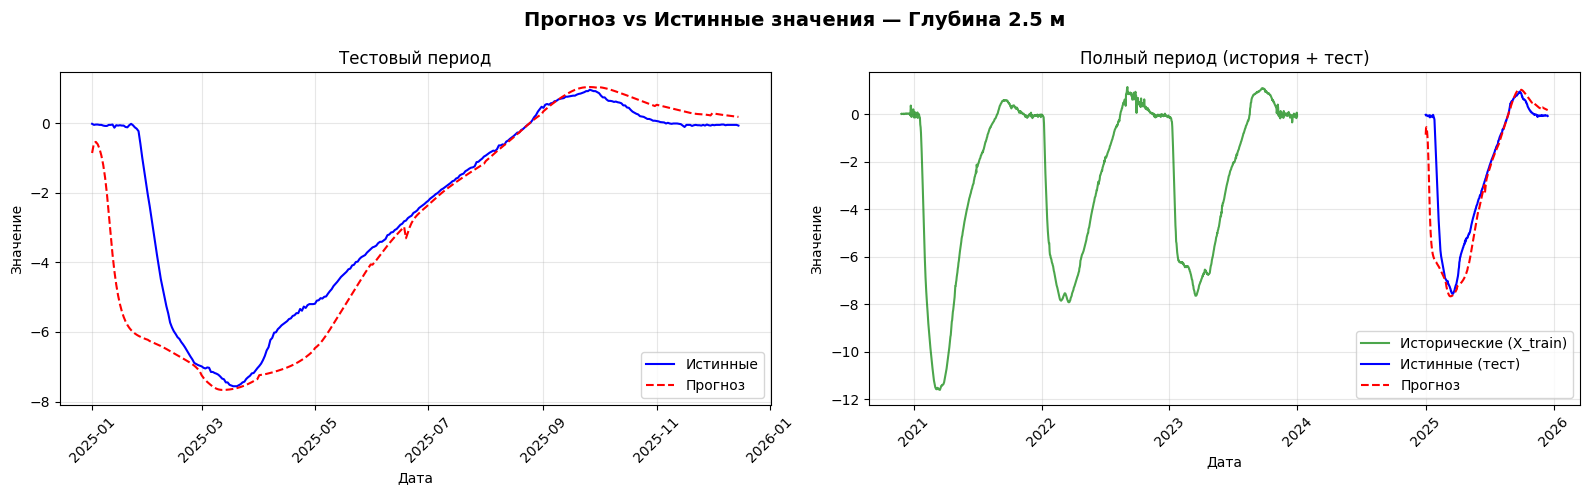

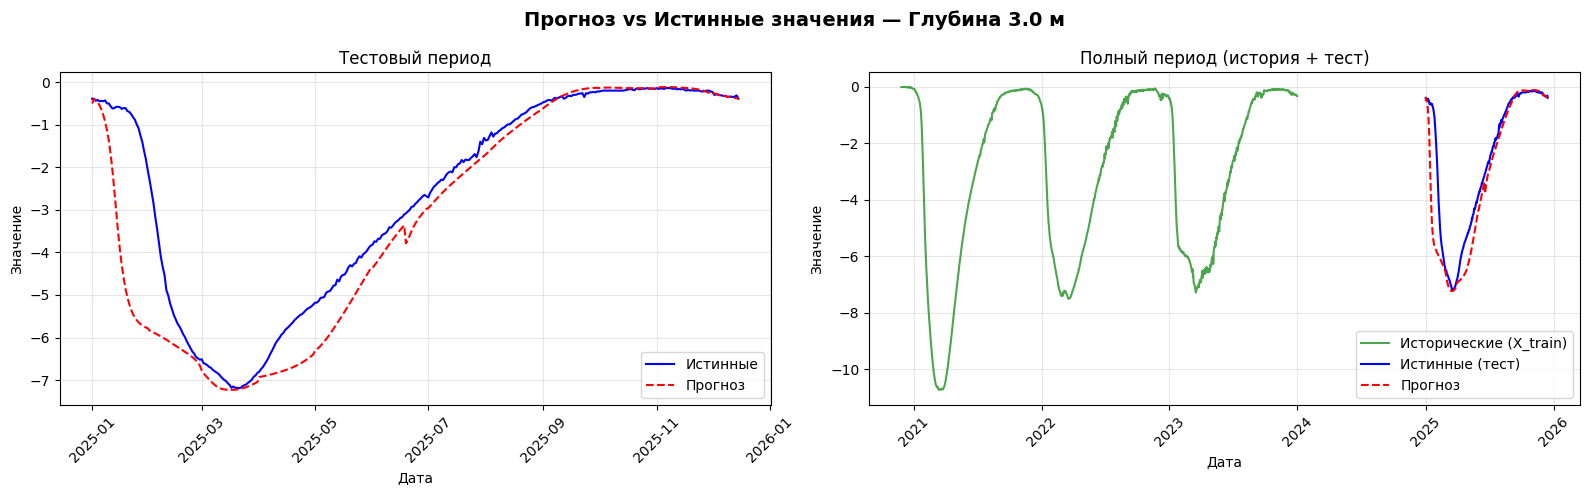

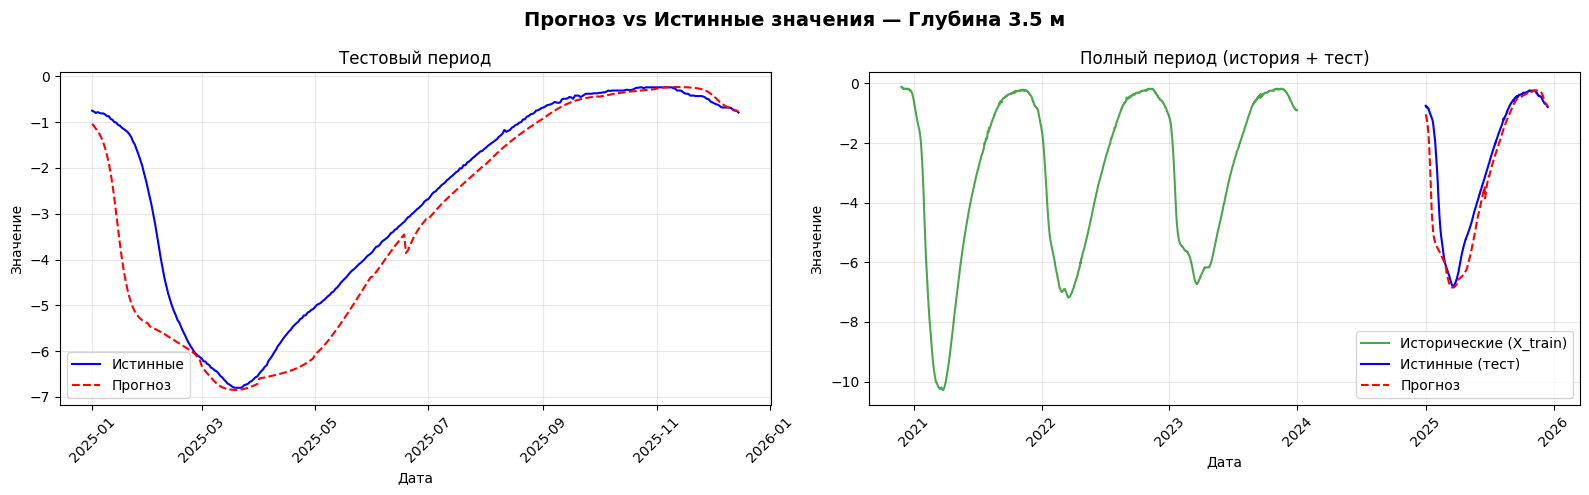

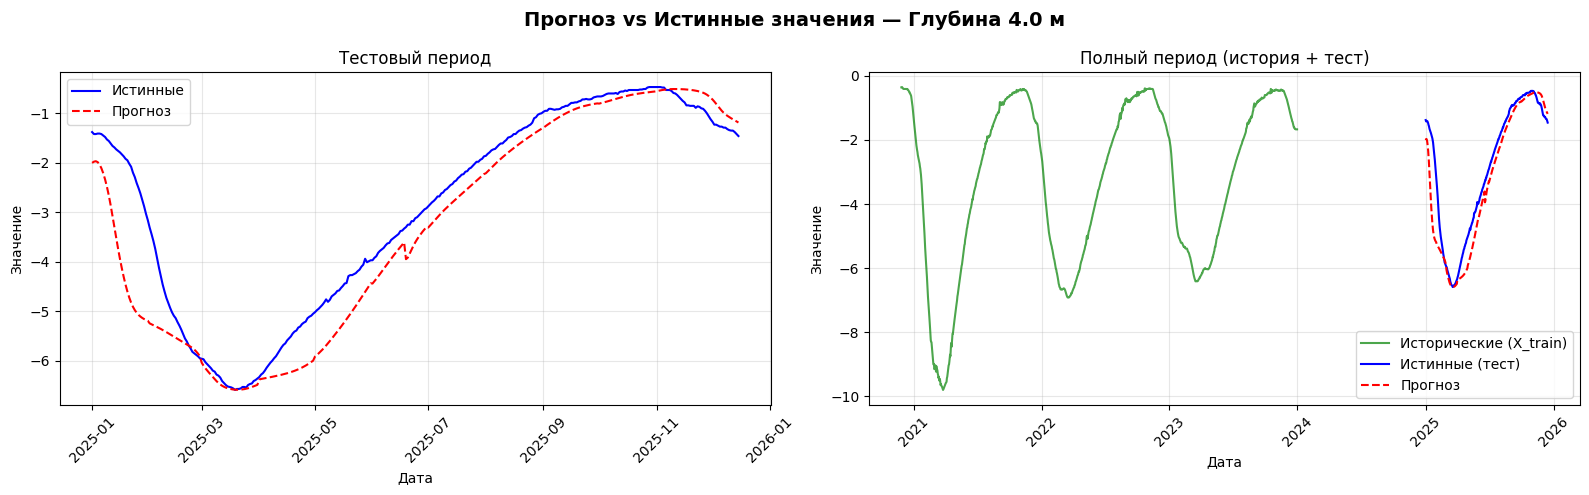

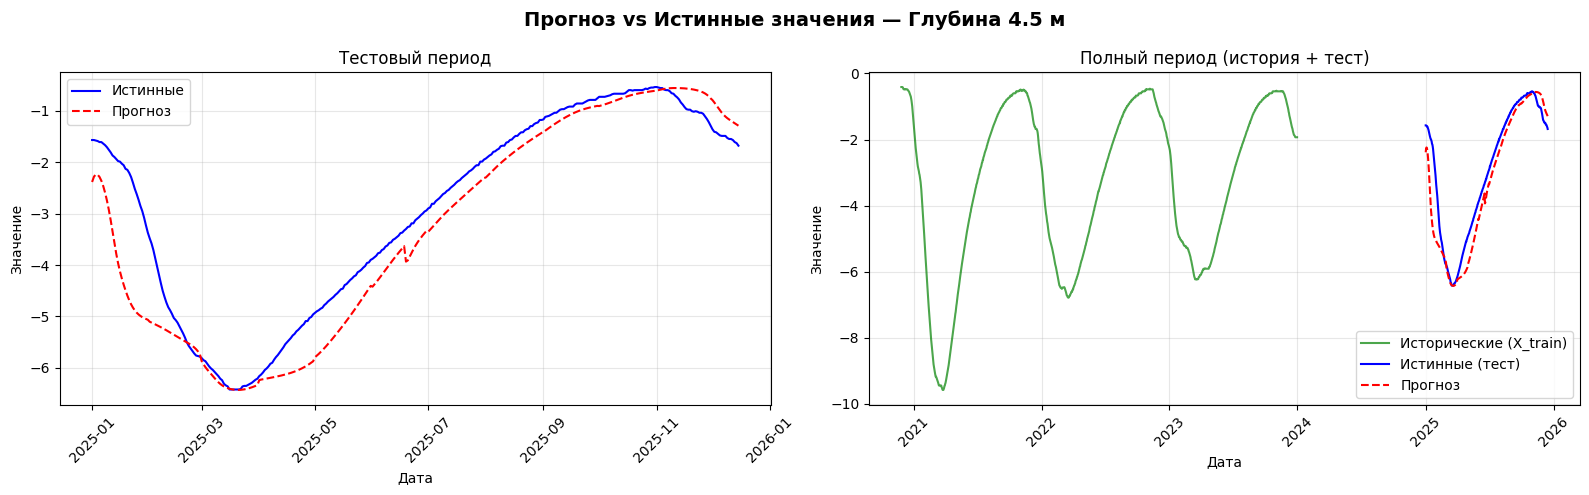

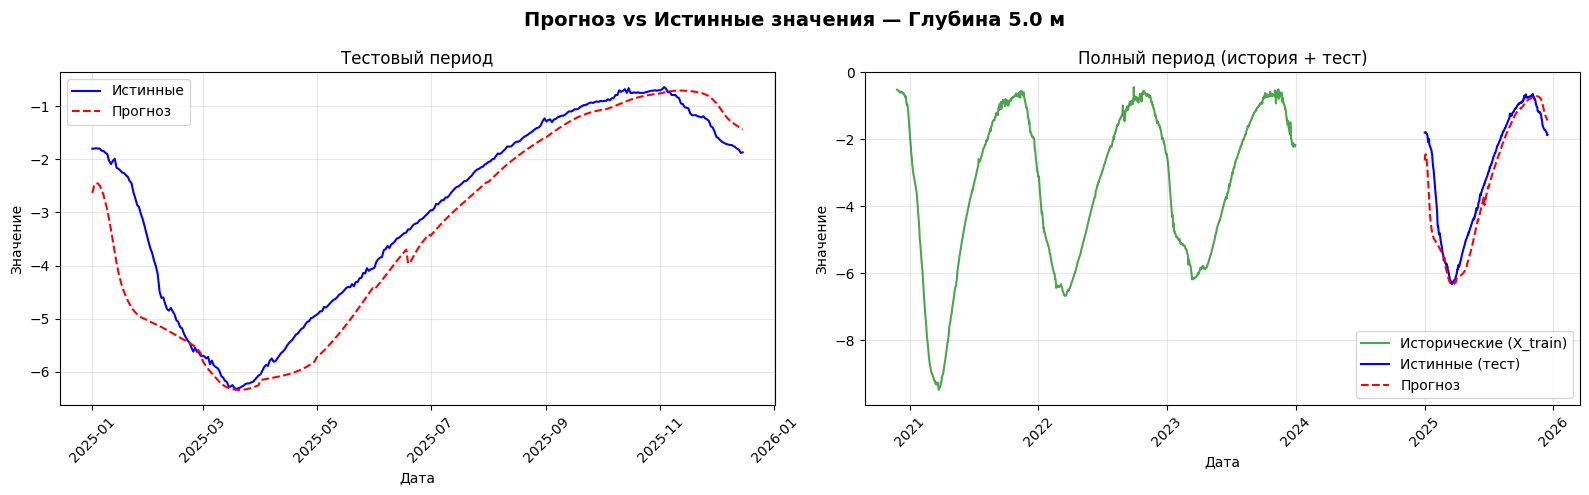

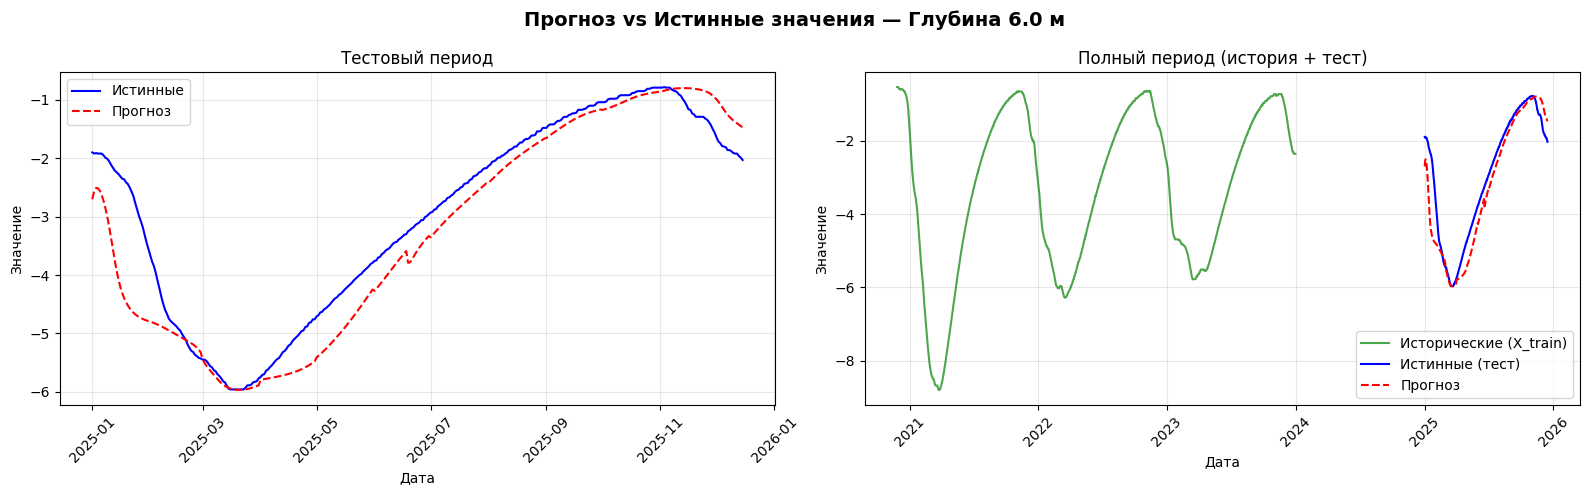

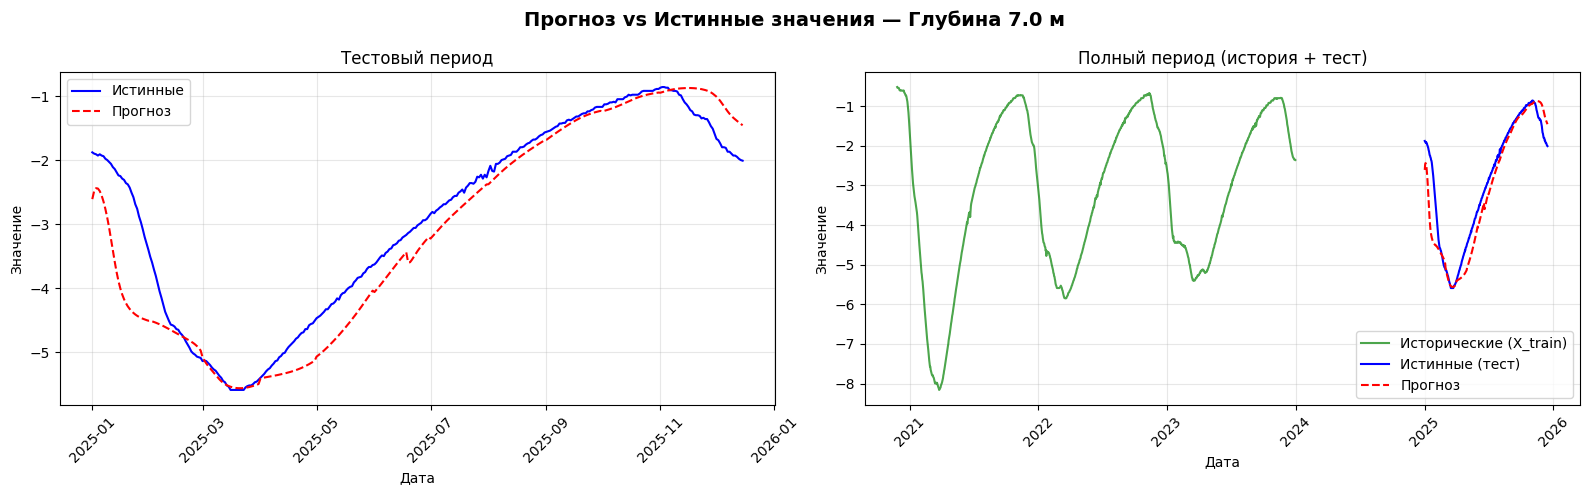

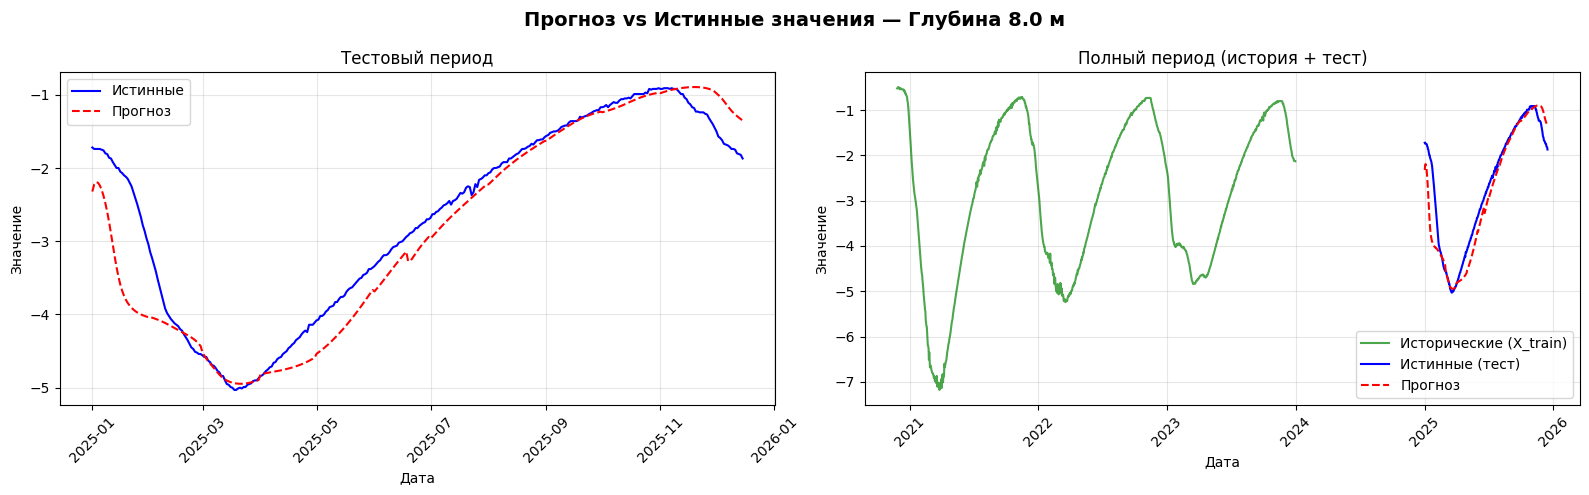

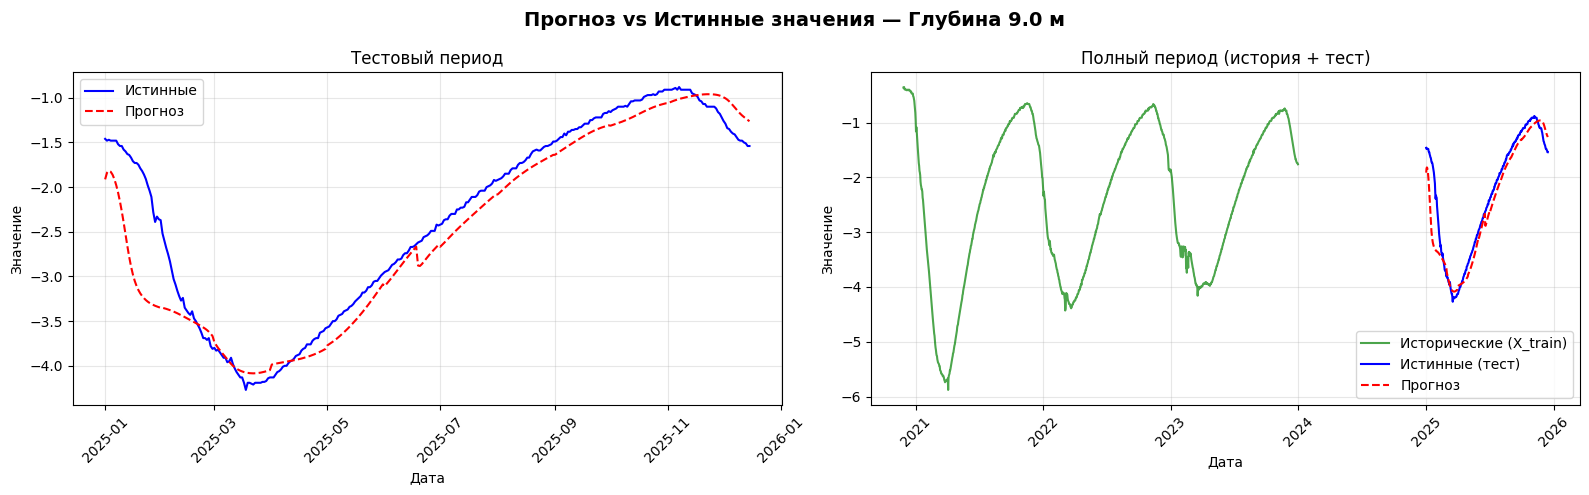

In [63]:
from src.visualization import plot_forecast_with_train
import pandas as pd

from darts.metrics import mae, rmse


actual_series = test_targets
depth_values = []
for ts in actual_series:
    depth_val = ts.static_covariates['depth_val'].iloc[0]
    depth_values.append(depth_val)

records = []
for depth, pred, actual in zip(depth_values, predictions, actual_series):
    mae_val = mae(actual, pred)
    rmse_val = rmse(actual, pred)
    records.append({
        'Depth, m': depth,
        'MAE': mae_val,
        'RMSE': rmse_val,
    })

metrics_df = pd.DataFrame(records)
print("Метрики по глубинам:")
print(metrics_df.to_string(index=False, float_format="%.3f"))

print("\nСредние метрики:")
avg = metrics_df[['MAE','RMSE']].mean()
print(f"MAE  = {avg['MAE']:.3f}")
print(f"RMSE = {avg['RMSE']:.3f}")

for i, depth in enumerate(depth_values):
    actual_ts = actual_series[i]
    pred_ts = predictions[i]

    train_ts = train_targets[i]
    val_ts = target_scaler.inverse_transform(val_scaled_targets)[i]
    train_val_ts = train_ts.append(val_ts)

    X_train = pd.Series(
        train_ts.values().flatten(),
        index=train_ts.time_index
    )
    y_true = pd.Series(
        actual_ts.values().flatten(),
        index=actual_ts.time_index
    )
    y_pred = pd.Series(
        pred_ts.values().flatten(),
        index=pred_ts.time_index
    )

    plot_forecast_with_train(
        X_train=X_train,
        y_true=y_true,
        y_pred=y_pred,
        title=f"Прогноз vs Истинные значения — Глубина {depth} м"
    )


In [66]:
from darts.explainability import TFTExplainer


explainer = TFTExplainer(
    model,
    background_series=val_scaled_targets[0],
    background_past_covariates=combined_past[0],
    background_future_covariates=combined_future[0]
)
explainability_result = explainer.explain()

Dataset output has a different data type than the dataset the model was trained on; current data type: float64, expected data type: float64. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 12.39it/s]


In [67]:
import pandas as pd
from IPython.display import display

raw_importances = explainability_result.get_feature_importances()
tables = dict()

for component_name, df_importance in raw_importances.items():

    if isinstance(df_importance, list):
        df_importance = df_importance[0]


    mean_importance = df_importance.mean(axis=0)

    df_component = pd.DataFrame({
        "Признак": mean_importance.index,
        "Важность (%)": mean_importance.values
    })

    if component_name in tables:
        tables[component_name].append(df_component)
    else:
        tables[component_name] = [df_component]

for key in tables:
    print(f"\nКАТЕГОРИЯ ПРИЗНАКОВ: {key.upper()}")
    tabel = tables[key]

    final_table = pd.concat(tabel, ignore_index=True)

    final_table = final_table.sort_values(by="Важность (%)", ascending=False)

    styled_table = (
        final_table.style
        .format({"Важность (%)": "{:.2f}%"})
        .bar(
            subset=["Важность (%)"],
            color="#d6e4ff",
            vmin=0,
            vmax=final_table["Важность (%)"].max()
        )
        .hide(axis='index')
    )

    display(styled_table)



КАТЕГОРИЯ ПРИЗНАКОВ: ENCODER_IMPORTANCE


Признак,Важность (%)
Месяц_cos_futcov,52.10%
Год_futcov,11.30%
day_of_year_sin_futcov,5.00%
day_of_year_futcov,4.90%
add_relative_index_futcov,4.60%
Месяц_sin_futcov,4.00%
air_temp_pastcov,3.70%
days_since_start_futcov,3.50%
temperature_target,3.50%
Месяц_futcov,2.50%



КАТЕГОРИЯ ПРИЗНАКОВ: DECODER_IMPORTANCE


Признак,Важность (%)
Месяц_cos_futcov,29.90%
add_relative_index_futcov,16.20%
day_of_year_sin_futcov,15.00%
День_futcov,9.60%
day_of_year_cos_futcov,9.40%
day_of_year_futcov,8.40%
days_since_start_futcov,5.60%
Год_futcov,2.50%
Месяц_sin_futcov,2.10%
Месяц_futcov,1.10%



КАТЕГОРИЯ ПРИЗНАКОВ: STATIC_COVARIATES_IMPORTANCE


Признак,Важность (%)
depth_id_statcov,87.80%
depth_val_statcov,12.20%
